In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sumo_rl
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
from sumo_rl.environment.observations import ObservationFunction
from gymnasium import spaces
from pathlib import Path

In [3]:
# Hyperparameters
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.97
batch_size = 64
learning_rate = 1e-3
num_seconds=1000
episodes = 50

In [4]:
def priority_reward_fn(ts):
    """
    Custom reward function that heavily penalizes stopped ambulances and buses.
    ts: The TrafficSignal object provided by sumo_rl.
    """
    reward = 0
    # Access the TraCI connection directly through the traffic signal
    traci = ts.sumo 
    
    # Iterate through all incoming lanes controlled by this specific traffic light
    for lane in ts.lanes:
        # Get the IDs of all vehicles currently on this lane
        vehicles = traci.lane.getLastStepVehicleIDs(lane)
        
        for veh in vehicles:
            # Get the vehicle's current speed
            speed = traci.vehicle.getSpeed(veh)
            
            # If the vehicle is practically stopped (waiting at a red light)
            if speed < 0.1:
                # Retrieve the vehicle type (defined in our .rou.xml file)
                v_type = traci.vehicle.getTypeID(veh)
                
                # Apply custom penalty weights
                if v_type == "ambulance":
                    reward -= 50.0  # Massive penalty for delaying an ambulance
                elif v_type == "bus":
                    reward -= 5.0   # Moderate penalty for delaying a bus
                else:
                    reward -= 1.0   # Standard penalty for normal cars
                    
    return reward

In [5]:
class PriorityObservationFunction(ObservationFunction):
    def __init__(self, ts):
        super().__init__(ts)
        # We need to define the shape of our observation array.
        # Let's say: [density_N, density_S, density_E, density_W, emergency_present_N, emergency_present_S...]
        pass 

    def __call__(self):

        traci = self.ts.sumo
        obs = []
        
        # normal traffic density
        density = self.ts.get_lanes_density()
        obs.extend(density)
        
        # whether an ambulance is waiting on each lane
        for lane in self.ts.lanes:
            emergency_waiting = 0.0
            vehicles = traci.lane.getLastStepVehicleIDs(lane)
            for veh in vehicles:
                if traci.vehicle.getTypeID(veh) == "ambulance":
                    emergency_waiting = 1.0
                    break
            obs.append(emergency_waiting)
            
        return np.array(obs, dtype=np.float32)

    def observation_space(self):
        return spaces.Box(low=0., high=1., shape=(len(self.ts.lanes) * 2,), dtype=np.float32)

In [6]:
# Initialize PettingZoo environment

base = Path("env_iiser") / "new"

route_files = [
    base / "vtypes.add.xml",
    base / "cars.rou.xml",
    base / "buses.rou.xml",
    base / "bikes.rou.xml",
    base / "ambulance.rou.xml",
]

net_path = str(base / "map.net.xml")

route = ",".join(str(p) for p in route_files)

env = sumo_rl.parallel_env(
    net_file=net_path,
    route_file=route,
    reward_fn=priority_reward_fn,
    observation_class=PriorityObservationFunction,
    use_gui=False, # Keep False for training
    num_seconds=num_seconds,
    delta_time=5,
    sumo_warnings = False
)

In [7]:
# Get dimensions for the network
sample_agent = env.possible_agents[0]
obs_dim = env.observation_space(sample_agent).shape[0]
action_dim = env.action_space(sample_agent).n

In [8]:
print(obs_dim)
print(action_dim)

6
2


In [9]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(obs_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [10]:
# Initialize Dictionaries for Networks, Optimizers, and Buffers
q_nets = {}
optimizers = {}
replay_buffers = {}
loss_fn = nn.MSELoss()

for agent in env.possible_agents:
    obs_dim = env.observation_space(agent).shape[0]
    action_dim = env.action_space(agent).n
    
    q_nets[agent] = QNetwork(obs_dim, action_dim)
    optimizers[agent] = optim.Adam(q_nets[agent].parameters(), lr=learning_rate)
    replay_buffers[agent] = deque(maxlen=10000)

In [ ]:
all_episode_rewards = []

for episode in range(episodes):
    observations, infos = env.reset()
    episode_reward = 0
    
    while env.agents:
        actions = {}
        
        # Epsilon-Greedy Action Selection
        for agent in env.agents:
            obs_tensor = torch.FloatTensor(observations[agent]).unsqueeze(0)
            
            if random.random() < epsilon:
                # Explore
                actions[agent] = env.action_space(agent).sample()
            else:
                # Exploit
                with torch.no_grad():
                    q_values = q_nets[agent](obs_tensor)
                    actions[agent] = torch.argmax(q_values).item()

        # Step the Environment 
        next_observations, rewards, terminations, truncations, infos = env.step(actions)

        # Store Transitions
        for agent in env.agents:
            replay_buffers[agent].append((
                observations[agent], 
                actions[agent], 
                rewards[agent], 
                next_observations[agent], 
                terminations[agent] or truncations[agent]
            ))
            episode_reward += rewards[agent]

            # Train the specific agent's Q-Network
            if len(replay_buffers[agent]) > batch_size:
                batch = random.sample(replay_buffers[agent], batch_size)
                b_obs, b_act, b_rew, b_next_obs, b_done = zip(*batch)
                
                b_obs = torch.FloatTensor(np.array(b_obs))
                b_act = torch.LongTensor(b_act).unsqueeze(1)
                b_rew = torch.FloatTensor(b_rew).unsqueeze(1)
                b_next_obs = torch.FloatTensor(np.array(b_next_obs))
                b_done = torch.FloatTensor(b_done).unsqueeze(1)

                current_q = q_nets[agent](b_obs).gather(1, b_act)
                
                with torch.no_grad():
                    max_next_q = q_nets[agent](b_next_obs).max(1)[0].unsqueeze(1)
                    target_q = b_rew + (gamma * max_next_q * (1 - b_done))
                
                loss = loss_fn(current_q, target_q)
                optimizers[agent].zero_grad()
                loss.backward()
                optimizers[agent].step()

        observations = next_observations

    all_episode_rewards.append(episode_reward)

    # Decay Epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    print(f"Episode {episode + 1} | Total Shared Reward: {episode_reward:.2f} | Epsilon: {epsilon:.2f}")

env.close()

Episode 1 | Total Shared Reward: -1147.00 | Epsilon: 0.97
Episode 2 | Total Shared Reward: -840.00 | Epsilon: 0.94
Episode 3 | Total Shared Reward: -835.00 | Epsilon: 0.91
Episode 4 | Total Shared Reward: -754.00 | Epsilon: 0.89
Episode 5 | Total Shared Reward: -865.00 | Epsilon: 0.86
Episode 6 | Total Shared Reward: -650.00 | Epsilon: 0.83
Episode 7 | Total Shared Reward: -615.00 | Epsilon: 0.81
Episode 8 | Total Shared Reward: -707.00 | Epsilon: 0.78
Episode 9 | Total Shared Reward: -629.00 | Epsilon: 0.76
Episode 10 | Total Shared Reward: -474.00 | Epsilon: 0.74
Episode 11 | Total Shared Reward: -649.00 | Epsilon: 0.72
Episode 12 | Total Shared Reward: -520.00 | Epsilon: 0.69
Episode 13 | Total Shared Reward: -474.00 | Epsilon: 0.67
Episode 14 | Total Shared Reward: -607.00 | Epsilon: 0.65
Episode 15 | Total Shared Reward: -639.00 | Epsilon: 0.63
Episode 16 | Total Shared Reward: -408.00 | Epsilon: 0.61
Episode 17 | Total Shared Reward: -511.00 | Epsilon: 0.60
Episode 18 | Total Sha

In [ ]:
# for agent in env.possible_agents:
#     model_path = f"./models/iiser/{agent}.pth"
#     torch.save(q_nets[agent].state_dict(), model_path)


for agent in env.possible_agents:
    model_path = Path("models") / "iiser_priority" / f"{agent}.pth"
    torch.save(q_nets[agent].state_dict(), str(model_path)) 

In [ ]:
def plot_rewards(rewards, window_size=5):
    plt.figure(figsize=(10, 5))
    
    plt.plot(rewards, label='Raw Episode Reward', color='dodgerblue', alpha=0.5)
    
    if len(rewards) >= window_size:
        window = np.ones(window_size) / window_size
        
        smoothed_rewards = np.convolve(rewards, window, mode='valid')
        
        x_values = range(window_size - 1, len(rewards))
        
        plt.plot(x_values, smoothed_rewards, label=f'Moving Average (Window={window_size})', color='darkorange', linewidth=2)
    
    plt.title('Independent DQN Training')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.savefig('training_curve.png')
    plt.show()

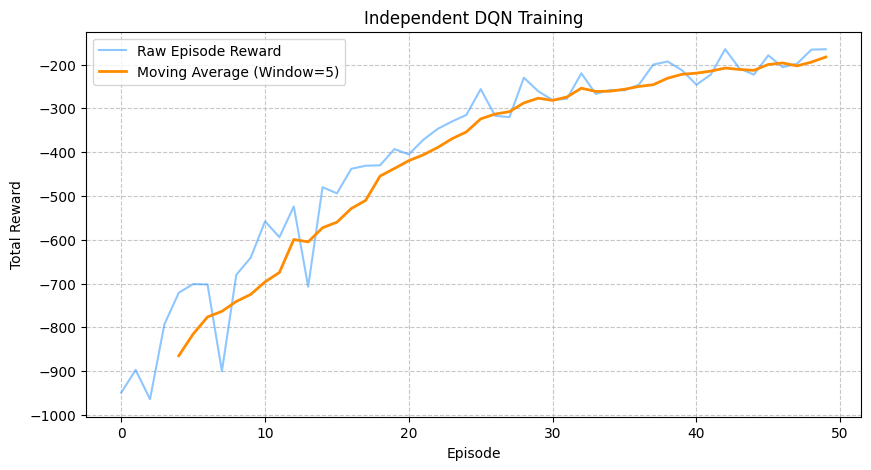

In [22]:
plot_rewards(all_episode_rewards)

In [14]:
def evaluate_model():
    
    env = sumo_rl.parallel_env(
        net_file = net_path,
        route_file = route,
        use_gui=True,
        num_seconds=600,   
        delta_time=5,
        observation_class=PriorityObservationFunction,
        reward_fn=priority_reward_fn
    )

    # Re-initialize and load models for each agent
    eval_q_nets = {}
    for agent in env.possible_agents:
        obs_dim = env.observation_space(agent).shape[0]
        action_dim = env.action_space(agent).n
        eval_q_nets[agent] = QNetwork(obs_dim, action_dim)
        
        try:
            eval_q_nets[agent].load_state_dict(torch.load(str(Path("models") / "iiser_priority" / f"{agent}.pth" )))
            eval_q_nets[agent].eval()
        except FileNotFoundError:
            print(f"Error: Could not find the model for {agent}.")
            return

    print("Models loaded successfully!")

    # Run the Simulation Loop
    observations, infos = env.reset()
    total_evaluation_reward = 0
    
    while env.agents:
        actions = {}
        for agent in env.agents:
            obs_tensor = torch.FloatTensor(observations[agent]).unsqueeze(0)
            with torch.no_grad():
                q_values = eval_q_nets[agent](obs_tensor)
                actions[agent] = torch.argmax(q_values).item() 

        observations, rewards, terminations, truncations, infos = env.step(actions)

        for agent in env.agents:
            total_evaluation_reward += rewards[agent]

    print(f"Simulation Finished. Final Total Reward: {total_evaluation_reward:.2f}")
    env.close()

In [15]:
evaluate_model()

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 47ms, vehicles TOT 0 ACT 0 BUF 0)                     
Models loaded successfully!
 Retrying in 1 seconds
Simulation Finished. Final Total Reward: -69.00


In [16]:
env.close()